In [26]:


# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)



Setup complete. NumPy 2.0.2


In [27]:
# -----------------------------------------------------------
# 🔹 1A. THE FOUR CONTAINERS
# -----------------------------------------------------------

scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')

scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [28]:
# -----------------------------------------------------------
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape
# -----------------------------------------------------------

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())


A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [29]:
T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
# YOUR CODE HERE

# 2. T + T
# YOUR CODE HERE

# 3. Transpose (print .T.shape) and reshape to (2, 6)
# YOUR CODE HERE

import numpy as np

T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
print("ndim:", T.ndim)
print("shape:", T.shape)

# 2. T + T
print("T + T:\n", T + T)

# 3. Transpose and reshape
print("Transpose shape:", T.T.shape)
print("Reshaped T:\n", T.reshape(2, 6))

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
ndim: 2
shape: (3, 4)
T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
Transpose shape: (4, 3)
Reshaped T:
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


2. Dot & cross products, and norms

In [30]:
# -----------------------------------------------------------
# 🔹 2A. DOT & CROSS PRODUCTS
# -----------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

# Dot product: sum of element-wise products -> measures alignment
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

# Cross product: a new vector perpendicular to both (3-D only)
print('a x b  (cross) :', np.cross(a, b))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [31]:
# -----------------------------------------------------------
# 🔹 2B. NORMS (vector length) + COSINE SIMILARITY
# -----------------------------------------------------------

print('L2 norm  ||a||_2 :', la.norm(a))         # sqrt(sum of squares)
print('L1 norm  ||a||_1 :', la.norm(a, 1))      # sum of absolute values
print('Linf norm        :', la.norm(a, np.inf)) # max absolute value

# Cosine similarity: the angle between vectors, ignoring magnitude
def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))

L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


In [33]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    # 2. cosine similarity of u and v
    # YOUR CODE HERE
    pass

# 3. Most similar pair = ?   (write your answer here)
import numpy as np

pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

cosine_scores = []

for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    l1 = np.linalg.norm(u, ord=1)
    l2 = np.linalg.norm(u, ord=2)

    # 2. Cosine similarity of u and v
    cosine = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    cosine_scores.append(cosine)

    print(f"Pair {i}:")
    print("L1 norm of u:", l1)
    print("L2 norm of u:", l2)
    print("Cosine similarity:", cosine)
    print()

# 3. Most similar pair
most_similar = np.argmax(cosine_scores) + 1
print("Most similar pair =", most_similar)

Pair 1:
L1 norm of u: 2.0
L2 norm of u: 1.4142135623730951
Cosine similarity: 0.9999999999999998

Pair 2:
L1 norm of u: 6.0
L2 norm of u: 3.7416573867739413
Cosine similarity: 0.7142857142857143

Pair 3:
L1 norm of u: 2.0
L2 norm of u: 2.0
Cosine similarity: 0.0

Most similar pair = 1


3. Matrix operations & special matrices

In [35]:
# -----------------------------------------------------------
# 🔹 3A. CORE MATRIX OPERATIONS
# -----------------------------------------------------------

A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))


A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]
trace(A) = sum of diagonal: 5.0


In [36]:
# -----------------------------------------------------------
# 🔹 3B. SPECIAL MATRICES: identity, symmetric, orthogonal
# -----------------------------------------------------------

I = np.eye(2)                       # identity: 1s on the diagonal
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))

# Symmetric: A equals its own transpose
print('A symmetric?', np.allclose(A, A.T))

# Orthogonal: Q.T @ Q == I (a pure rotation/reflection)
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? True


In [38]:


M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
# YOUR CODE HERE

# 2. M @ inv(M) == I ?
# YOUR CODE HERE

# 3. Is M symmetric? Is P orthogonal?
# YOUR CODE HERE

import numpy as np

M = np.array([[4., 2.],
              [2., 3.]])

P = np.array([[0., -1.],
              [1.,  0.]])

# 1. Inverse and trace of M
inv_M = np.linalg.inv(M)

print("inverse(M):")
print(inv_M)
import numpy as np

def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Toy 4-D embeddings
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))
print('cosine(king, apple):', round(cosine(king, apple), 3))
print("trace(M):")
print(np.trace(M))

# 2. M @ inverse(M) == I ?
I = np.eye(2)
print("M @ inverse(M) is identity:",
      np.allclose(M @ inv_M, I))

# 3. Is M symmetric? Is P orthogonal?
print("M is symmetric:",
      np.allclose(M, M.T))

print("P is orthogonal:",
      np.allclose(P.T @ P, np.eye(2)))

inverse(M):
[[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
trace(M):
7.0
M @ inverse(M) is identity: True
M is symmetric: True
P is orthogonal: True


4. Transformations: rotation & scaling

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],import numpy as np

def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Toy 4-D embeddings
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))
print('cosine(king, apple):', round(cosine(king, apple), 3))
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)

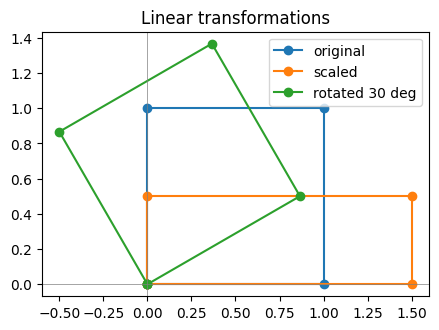

In [39]:
# -----------------------------------------------------------
# 🔹 4B. PLOT ORIGINAL vs TRANSFORMED
# -----------------------------------------------------------

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

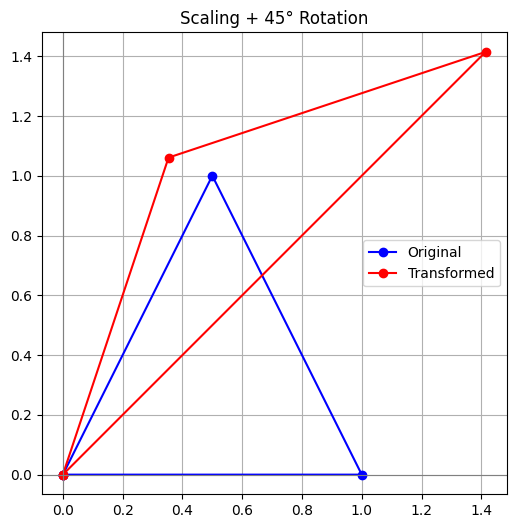

In [41]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# 1. Scaling matrix (x*2, y*0.5)
# YOUR CODE HERE

# 2. Rotation matrix (45 degrees)
# YOUR CODE HERE

# 3. Apply both and plot original vs transformed
# YOUR CODE HERE

import numpy as np
import matplotlib.pyplot as plt

tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# Helper function to close the triangle
def close_loop(X):
    return np.hstack([X, X[:, :1]])

# 1. Scaling matrix: x * 2, y * 0.5
S = np.array([[2, 0],
              [0, 0.5]])

# 2. Rotation matrix: 45 degrees
theta = np.deg2rad(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# 3. Apply both transformations
# First scale, then rotate
tri_transformed = R @ (S @ tri)

# Close loops for plotting
tri_closed = close_loop(tri)
transformed_closed = close_loop(tri_transformed)

# Plot original vs transformed
plt.figure(figsize=(6, 6))

plt.plot(tri_closed[0], tri_closed[1],
         'bo-', label='Original')

plt.plot(transformed_closed[0], transformed_closed[1],
         'ro-', label='Transformed')

plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.title('Scaling + 45° Rotation')

plt.show()


5. Eigenvalues & eigenvectors

In [42]:


# -----------------------------------------------------------
# 🔹 5A. COMPUTE EIGENVALUES & EIGENVECTORS
# -----------------------------------------------------------

A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)     # vals = eigenvalues, vecs columns = eigenvectors
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)



Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]


In [43]:
# -----------------------------------------------------------
# 🔹 5B. VERIFY  A v = lambda v
# -----------------------------------------------------------

for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = A @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))


lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


In [56]:
C = np.array([[4., 1.],
              [2., 3.]])

# 1. eigenvalues and eigenvectors
# YOUR CODE HERE

# 2. print eigenvalues
# YOUR CODE HERE

# 3. verify A v = lambda v for the first eigenvector
# YOUR CODE HERE
import numpy as np
import numpy.linalg as la

C = np.array([[4., 1.],
              [2., 3.]])

# 1. Eigenvalues and eigenvectors
eigenvalues, eigenvectors = la.eig(C)

# 2. Print eigenvalues
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

# 3. Verify C @ v = lambda * v for the first eigenvector
v = eigenvectors[:, 0]
lam = eigenvalues[0]

print("Verification:", np.allclose(C @ v, lam * v))

Eigenvalues: [5. 2.]
Eigenvectors:
 [[ 0.707 -0.447]
 [ 0.707  0.894]]
Verification: True


6. Rank, solving systems & cosine similarity

In [45]:


# -----------------------------------------------------------
# 🔹 6A. SOLVE A 3x3 SYSTEM  A x = b
# -----------------------------------------------------------

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

x = la.solve(A, b)
print('Solution x:', x)                    # [2, 3, -1]
print('Rank of A :', la.matrix_rank(A))     # 3 -> full rank
print('Full rank -> a unique solution exists')



Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists


In [46]:

# -----------------------------------------------------------
# 🔹 6B. RANK TELLS YOU SOLVABILITY
# -----------------------------------------------------------

# A rank-deficient matrix: row 3 = row 1 + row 2 (not independent)
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')

Rank of D: 2 -> < 3, so rows are dependent


In [47]:

# -----------------------------------------------------------
# 🔹 6B. RANK TELLS YOU SOLVABILITY
# -----------------------------------------------------------

# A rank-deficient matrix: row 3 = row 1 + row 2 (not independent)
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')


Rank of D: 2 -> < 3, so rows are dependent


In [61]:
import numpy as np

def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Toy 4-D embeddings
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))
print('cosine(king, apple):', round(cosine(king, apple), 3))

cosine(king, queen): 0.986
cosine(king, apple): 0.267


In [60]:
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
# YOUR CODE HERE

# 2. Rank of A2
# YOUR CODE HERE

# 3. cosine(cat, dog) and cosine(cat, car); which is more similar?
# YOUR CODE HERE
import numpy as np

A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
x = np.linalg.solve(A2, b2)
print("Solution x:", x)

# 2. Rank of A2
rank = np.linalg.matrix_rank(A2)
print("Rank of A2:", rank)

# 3. Cosine similarity
cos_cat_dog = np.dot(cat, dog) / (np.linalg.norm(cat) * np.linalg.norm(dog))
cos_cat_car = np.dot(cat, car) / (np.linalg.norm(cat) * np.linalg.norm(car))

print("Cosine similarity (cat, dog):", cos_cat_dog)
print("Cosine similarity (cat, car):", cos_cat_car)

if cos_cat_dog > cos_cat_car:
    print("More similar: cat and dog")
else:
    print("More similar: cat and car")

Solution x: [1. 2.]
Rank of A2: 2
Cosine similarity (cat, dog): 0.9946195449838785
Cosine similarity (cat, car): 0.29255678516966266
More similar: cat and dog
